**Get the Dataset**

In [2]:
import pandas as pd


In [3]:
df = pd.read_csv('placement.xls')

In [4]:
df.shape

(200, 2)

In [5]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


**Plot the data to see the relationship between CGPA and package**

In [6]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'package')

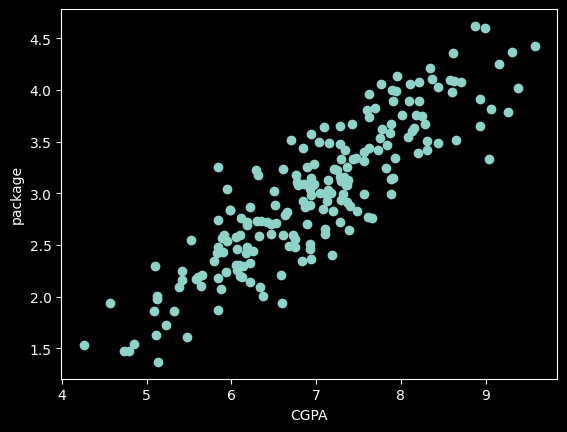

In [7]:
plt.scatter(df['cgpa'], df['package'])
plt.xlabel('CGPA')
plt.ylabel('package')

**Split the data into training and testing sets**

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
x_train, x_test, y_train, y_test = train_test_split(df['cgpa'], df['package'], test_size=0.3, random_state=2)

**Train the linear regression model using the training data**

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(df['cgpa'].values.reshape(-1, 1), df['package'])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
model.coef_

array([0.56959129])

In [12]:
model.intercept_

np.float64(-0.9856779462557332)

In [13]:
y_pred = model.predict(x_test.values.reshape(-1, 1))

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

**Plot the regression line along with the test data points**

Text(0, 0.5, 'package')

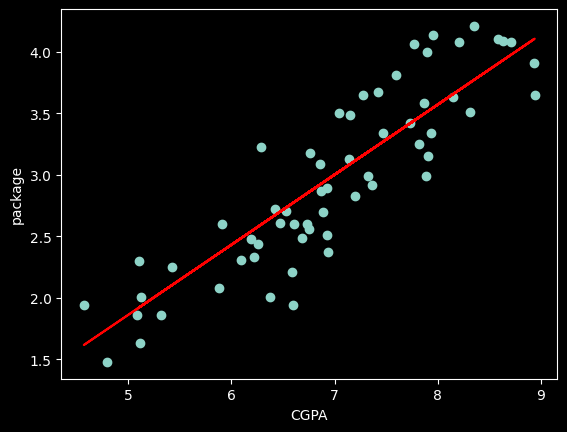

In [15]:
plt.scatter(x_test, y_test)
plt.plot(x_test, y_pred, color='red')
plt.xlabel('CGPA')
plt.ylabel('package')

In [16]:
y_test, y_pred

(112    4.10
 29     3.49
 182    2.08
 199    2.33
 193    1.94
 85     1.48
 10     1.86
 54     3.09
 115    4.21
 35     2.87
 12     3.65
 92     4.00
 13     2.89
 126    2.60
 174    2.99
 2      3.25
 44     1.86
 3      3.67
 113    2.37
 14     3.42
 23     2.48
 25     3.65
 6      2.60
 134    2.83
 165    4.08
 173    2.56
 45     3.58
 65     3.81
 48     4.09
 122    2.01
 178    3.63
 64     2.92
 9      3.51
 57     1.94
 78     2.21
 71     3.34
 128    3.34
 176    3.23
 131    2.01
 53     2.61
 137    3.13
 163    3.91
 111    2.25
 123    2.30
 109    4.06
 141    3.18
 41     2.70
 130    2.49
 140    3.15
 5      2.99
 159    4.08
 100    4.14
 11     2.60
 187    2.44
 24     2.71
 89     2.72
 66     1.63
 8      2.31
 172    2.51
 175    3.50
 Name: package, dtype: float64,
 array([3.90141536, 3.08689981, 2.36351887, 2.55717991, 1.61735427,
        1.74266436, 2.04454774, 2.92171834, 3.77040937, 2.92741425,
        4.10646823, 3.51409328, 2.96158973, 2.380606

**Find the error metrics for the model**

In [26]:
mean_squared_error(y_test, y_pred)

0.11670406617181926

In [18]:
mean_absolute_error(y_test, y_pred)

0.2840787373073058

In [19]:
r2_score(y_test, y_pred)

0.7772397577343819

In [20]:
first_cgpa = x_test.values[0];

In [25]:
predicted_package = model.predict(first_cgpa.reshape(-1, 1))[0]

In [22]:
actual_package = y_test.values[0];

In [23]:
print(f"CGPA: {first_cgpa}")
print(f"Predicted Package: {predicted_package:.2f} LPA")
print(f"Actual Package: {actual_package:.2f} LPA")
print(f"Difference: {abs(predicted_package - actual_package):.2f} LPA")

CGPA: 8.58
Predicted Package: 3.90 LPA
Actual Package: 4.10 LPA
Difference: 0.20 LPA
